<a href="https://colab.research.google.com/github/SkylarOu9005/Handwriting-Recognition-Model-Training/blob/main/%E6%89%8B%E5%AF%AB%E8%BE%A8%E8%AD%98%E6%A8%A1%E5%9E%8B%E8%A8%93%E7%B7%B4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **手寫辨識模型訓練**
專案目標：建構一個能夠辨識手寫數字0~9的神經網路，並建立UI介面提供user實際手寫測試。
</br>

## 層數與神經元數量設定摘要
<h4>我的隱藏層設定為兩層，並且神經元數量逐層遞減。<h4>
</br>以下是我經過多次的調整測試出「模型準確度最高」的隱藏層層數與神經元數量組合。此外，由於MNIST資料集相對比較小，過多的隱藏層和神經元可能會導致「過擬合（Overfitting）」，所以除了以下的兩個隱藏層，我也在每個隱藏層之間插入 Dropout 層，以及在模型的 compile 階段加入防止過度擬合的函數- EarlyStopping ，一次次進行微調，找出準確度最高的方法。


In [ ]:
N1 = 784
N2 = 392

# N3 = 196
# N4 = 98
# N5 = 49

#補充：我在這裡試了很多不同的版本：
#例如1-使用五層隱藏層，參數：全部都設20(準確度11%)、全部都設196(準確度90.11%)、N1-N5：512,256,128,64,32、或是N1-N5：784、392、196、98、49等等多種組合。
#例如2-使用兩層隱藏層，參數：N1=196、98(準確度97.97%)、N1=392,N2=196、N1=98、N2=98等等。
#所得的結果證實：1.神經元數量逐層遞減所得到的準確度較高 2.增加隱藏層會因為過擬合(Overfitting)的發生，效果反而不如用少量隱藏層(兩層)還要好。

## 1. 讀入套件

In [ ]:
!pip install gradio

In [ ]:
%matplotlib inline

# 標準數據分析、畫圖套件
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 神經網路方面
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.optimizers import Adam #我使用了在這個模型內表現得更好的Adam優化器。
from tensorflow.keras.layers import Dropout #我新增了Dropout層，來防止神經模型過度擬合；Dropout層會隨機丟棄一部分神經元，讓模型學習更強健的特徵。
from tensorflow.keras.callbacks import EarlyStopping #我在模型的compile階段使用了回調函數，當模型表現不再提高時自動停止訓練，防止過擬合。

# 互動設計用
from ipywidgets import interact_manual

# 神速打造 web app 的 Gradio
import gradio as gr

## 2.讀入MNIST數據庫

### 2.1 由 Keras 讀入 MNIST

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

檢查訓練資料是不是6萬筆、測試資料是否有1萬筆。(正確)

In [ ]:
print(f'訓練資料總筆數為 {len(x_train)} 筆資料')
print(f'測試資料總筆數為 {len(x_test)} 筆資料')

訓練資料總筆數為 60000 筆資料
測試資料總筆數為 10000 筆資料


檢查x_train的shape，結果顯示共有60000筆的資料，每筆資料是28x28的矩陣。(正確)

In [ ]:
x_train.shape

(60000, 28, 28)

隨機抓一個資料出來檢查一下。(ok)

In [ ]:
x_train[9999]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11,
         65,  76, 133, 202, 253, 253, 253, 124,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  61, 237,
        252, 252, 253, 250, 211, 135, 252, 187,   5,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   9, 128, 234, 252,
        252, 252, 228,  87,   0,  49, 252, 252,  48,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 141, 252, 252, 252,
        252, 206,  40,   0,   0, 129, 252, 204,  16,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  24, 215, 252, 252, 229,
         83,   4,   0,   0,   9, 189, 238,  80,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 146, 252, 153,  37,
          0,   0,   0,   7, 156, 252, 192,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  12,  48,   9,   0,
          0,   0,   0,  25, 252, 252, 151,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 169, 252, 164,  10,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 132, 252, 236,  48,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 116, 248, 252, 158,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         64, 248, 255, 223,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  56,
        242, 252, 241,  98,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 171,
        252, 252, 104,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 137, 241,
        252, 206,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  18, 216, 252,
        252,  11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  47, 210, 252, 252,
         77,   3,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 101, 252, 252, 133,
          5,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

### 2.2 輸入格式整理
由於標準神經網路只吃平坦的一維張量，所以我需要將原本28x28的矩陣攤平。
攤平完成後再檢查一下是否為28x28=784長的張量。(正確
)

In [ ]:
x_train = x_train.reshape(60000, 784)/255
x_test = x_test.reshape(10000, 784)/255

In [ ]:
x_train.shape

(60000, 784)

### 2.3 輸出格式整理
 將輸出轉為"1-hot enconding"模式。


In [ ]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

檢查有沒有改成one-hot encoding成功。(有)

In [ ]:
y_train[5678]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

## 3. 打造第一個神經網路

### 3.1 建構神經網路

在我的測試下，我觀察到使用兩層隱藏層以及N1、N2分別為784、392時，模型準確度有最好的表現。
</br>期間，我也觀察到模型出現了 Overfitting 的問題。
</br>所以，我在每個隱藏層之後都加入了 Dropout層，藉由丟棄部分神經元，來防止 Overfitting 的問題。
</br>
</br>除此之外，我也對激發函數進行了測試（例如：relu、sigmiod...），發現表現最佳的是所有隱藏層皆使用 relu，所以我全部都使用 relu。
</br>最後，在 Dropout 層丟掉神經元的比例，也是經過測試發現參數設置為0.3（丟掉30%的神經元），最有辦法保持模型準確度。

In [ ]:
model = Sequential()

In [ ]:
model.add(Dense(N1, input_dim=784, activation='relu')) #第一層隱藏層

In [ ]:
model.add(Dropout(0.3)) #插一層Dropout層

In [ ]:
model.add(Dense(N2, activation='relu')) #第二層隱藏層

In [ ]:
model.add(Dropout(0.3)) #插一層Dropout層

最後，由於輸出有10個數字,所以輸出層的神經元是10個；此外，利用 `softmax` 當激發函數，讓所有輸出的總和為1。

In [ ]:
model.add(Dense(10, activation='softmax'))

### 3.2 組裝神經網路
在 `compile` 的這個階段我對loss function和optimizer都進行了調整，
</br>`1.`我把 loss function 改為 categorical_crossentropy 這個更適合用於分類問題的損失函數。
</br>`2.`optimizer 改為 Adam （不用設置 learning rate，因為 Adam 會自動調整學習率）。

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

#補充：我使用optimizer=SGD(learning_rate=0.001)時，準確率僅有91.71%，所以後來選擇表現更好的Adam優化器。

## 4. 檢視我的神經網路

In [ ]:
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                     │ (None, 784)                 │         615,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_28 (Dropout)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 392)                 │         307,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_29 (Dropout)                 │ (None, 392)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_44 (Dense)                     │ (None, 10)                  │           3,930 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 927,090 (3.54 MB)

 Trainable params: 927,090 (3.54 MB)

 Non-trainable params: 0 (0.00 B)

## 5. 訓練神經網路


`1.` 我設定 batch_size =55、 epochs =20來訓練模型，
</br>`2.` 並加上 EarlyStopping 回調函數來防止過度擬合。當驗證集的準確度不再提升或開始下降時，Early Stopping 會使模型提前停止訓練。所以有可能還不到設定的epochs時就停止訓練（因為驗證準確度val_accuracy不再上升，而訓練準確度accuracy仍在上升，代表我們的模型過度依賴訓練數據，無法有效地泛化到新的數據。）
</br>`3.` validation_spilt 設置為0.2，用意是將20%的訓練數據用來作為驗證集。
</br>`4.` 重要的是，訓練完後再將訓練紀錄的 accuracy 及 val_accuracy 用圖形化來表示出來，觀察是否有 Overfitting 的問題。以此來修正模型。

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5)
train_history = model.fit(x_train, y_train, batch_size=55, epochs=20, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/20
873/873 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8634 - loss: 0.4340 - val_accuracy: 0.9657 - val_loss: 0.1106
Epoch 2/20
873/873 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9621 - loss: 0.1250 - val_accuracy: 0.9740 - val_loss: 0.0869
Epoch 3/20
873/873 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9734 - loss: 0.0860 - val_accuracy: 0.9726 - val_loss: 0.0932
Epoch 4/20
873/873 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9779 - loss: 0.0688 - val_accuracy: 0.9747 - val_loss: 0.0837
Epoch 5/20
873/873 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9806 - loss: 0.0599 - val_accuracy: 0.9780 - val_loss: 0.0778
Epoch 6/20
873/873 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9839 - loss: 0.0514 - val_accuracy: 0.9788 - val_loss: 0.0779
Epoch 7/20
873/873 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9848 - loss: 0.0479 - val_accuracy: 0.9788 - val_loss: 0.0810
Epoch 8/20
873/873 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9865 - loss: 0.0417 - 

In [ ]:
import matplotlib.pyplot as plt
def show_train_history(train_history, key1, key2):
    # 畫出訓練準確率和驗證準確率的圖
    plt.plot(train_history.history[key1])
    plt.plot(train_history.history[key2])
    plt.title(f'Training and Validation {key1}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])
    plt.show()

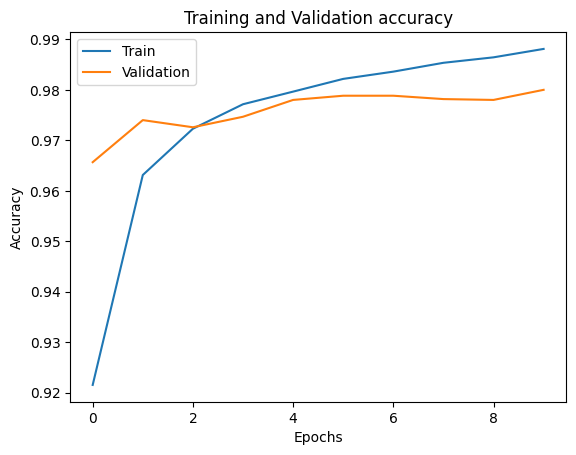

In [ ]:
show_train_history(train_history, 'accuracy', 'val_accuracy')

## 6. 結果總結

## 這是我的模型的資料正確率「總評量」：
</br> <h4>在以上條件下，模型的準確率98.34%<h4>


In [ ]:
loss, acc = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9795 - loss: 0.0873


In [ ]:
print('loss:', loss)
print(f"測試資料正確率 {acc*100:.2f}%")

loss: 0.07851510494947433
測試資料正確率 98.21%


<h4> 這邊的predict放了我的神經網路的學習結果。做完之後用 argmax 找到數值最大的那一項，存起來，等一下做測試! <h4>

In [ ]:
predict = np.argmax(model.predict(x_test), axis=-1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
predict

array([7, 2, 1, ..., 4, 5, 6])

<h4>這裡我將 `x_test` 從 784 維的向量, reshape 回 28x28 的矩陣，並將圖形顯示出來!
</br>並且測試一下。「正確率很高，基本上都正確，沒有測到失敗的情況」，
</br>這一步測試結束後，我們還可以用 Gradio 來「手寫」測試！<h4>


In [ ]:
def test(測試編號):
    plt.imshow(x_test[測試編號].reshape(28,28), cmap='Greys')
    print('神經網路判斷為:', predict[測試編號])

In [ ]:
interact_manual(test, 測試編號=(0, 9999));

interactive(children=(IntSlider(value=4999, description='測試編號', max=9999), Button(description='Run Interact', …

### 7. 用 Gradio 來展示

In [ ]:
def resize_image(inp):
    # 圖在 inp["layers"][0]
    image = np.array(inp["layers"][0], dtype=np.float32)
    image = image.astype(np.uint8)

    # 轉成 PIL 格式
    image_pil = Image.fromarray(image)

    # Alpha 通道設為白色, 再把圖從 RGBA 轉成 RGB
    background = Image.new("RGB", image_pil.size, (255, 255, 255))
    background.paste(image_pil, mask=image_pil.split()[3])
    image_pil = background

    # 轉換為灰階圖像
    image_gray = image_pil.convert("L")

    # 將灰階圖像縮放到 28x28, 轉回 numpy array
    img_array = np.array(image_gray.resize((28, 28), resample=Image.LANCZOS))

    # 配合 MNIST 數據集
    img_array = 255 - img_array

    # 拉平並縮放
    img_array = img_array.reshape(1, 784) / 255.0

    return img_array

In [ ]:
def recognize_digit(inp):
    img_array = resize_image(inp)
    prediction = model.predict(img_array).flatten()
    labels = list('0123456789')
    return {labels[i]: float(prediction[i]) for i in range(10)}

In [ ]:
iface = gr.Interface(
    fn=recognize_digit,
    inputs=gr.Sketchpad(),
    outputs=gr.Label(num_top_classes=3),
    title="MNIST 手寫辨識",
    description="請在畫板上繪製數字"
)

iface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a5f62159c5937e68c9.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://a5f62159c5937e68c9.gradio.live
